### Recap (Section 1):
        For my problem, I am solving the cooling with forced convection. This is done by taking an extreme difference in temperature for the initial phase, then slowly increasing the temperature (slow dynamic phase) afterwards. The governing ODE was:
    
    dT/dt = -h(T - Tinf(t))

    Standard Form:

    dT/dt = -1000T + 1000(300 + 50sin(0.01t))

    Where:
    T = Temperature
    h = Convection Coefficient
    t = Time
    T(0) = 500K
    
        The basic implicit solver used was the Backwards Eulers method using Newton-Raphson. The stiffness parameter would be the  is lambda = 1000, since the initial phase is caused by the difference of the extreme temperature in the initial temperature. It it stiff becuase there is a steep drop in temperature that occurs in fractions of a second, and then has a second slow dynamic phase. This causes explicit method solvers to fail unless there is an extremely small step, thereby causing inefficiency.

### Section 2:
    Explanation of damping and line search
    Implementation of damped NR solver
    Demonstration where damping helps (e.g., very large initial h)
    Comparison: basic NR vs. damped NR convergence
    
    Damping is a factor used when the following issues arise: Initial guess is far from solution, step size is too large, function is highly nonlinear, and the updates diverges. The main idea of a line search is to have a residual and ensure it decreases at each iteration, adjusting the damping factor. This allows for adaptive step size control, where rate of change of the solution changes depending on the region.
    
    Implementing the damped NR solver would be by adding a damping factor to the NR:
    
    y^(k+1) = y^(k) - a(g(y^(k))/g'(y^(k))
    
    where:
    a exist between (0, 1]
    a = 1 is full Newton-Raphson 
    a < 1a is taking smaller steps (convergence is difficult)
    
    Damping would be crucial when there are factors such as a very large initial h or an inaccurate initial guess. A basic NR would have trouble converging when these factors arise, thereby wasting computational resources.
    
    Note: Due ot the nature of the linear ODE, the derivative g'(T) is constant, therefore the basic NR will not fail. It  will always converge to Iterations = 2. Damped algortihms are integrated whenever there are nonlinear ODEs or cases.
  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T0 = 500
t0 = 0
tf = 30
h = 0.5

def f(t, T):
    return (-1000*T) + 1000*(300 + 50*np.sin(0.01*t))

def analytical_solution(t):
    return 200 * np.exp(-1000 * t) + 300 + 50 * np.sin(0.01 * t)

def g_func(T_guess, T_n, t_next, h):
    return T_guess - T_n - h * f(t_next, T_guess)

def dg(h):
    return 1 + 1000*h


# Damped Newton Raphson
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k, True
        
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False
        
        y_guess = y_new
    
    return y_guess, max_iter, False

# Parameters
T0 = 500
t0 = 0
tf = 30
h = 0.5


y_value, iterations, T_F = damped_newton_raphson(T0, t0 + h, h, g_func, dg)

print(f'y-val: {y_value}')
print(f'iterations: {iterations}')
print(f'converges:{T_F}')

# Large initial h
h = 100

y_value, iterations, T_F = damped_newton_raphson(T0, t0 + h, h, g_func, dg)

print(f'y-val: {y_value}')
print(f'iterations: {iterations}')
print(f'converges:{T_F}')



y-val: 300.6487015552242
iterations: 1
converges:True
y-val: 342.07512848910994
iterations: 1
converges:True


As seen, it helps converge even high initial h values.

In [2]:
#Comparison between basic NR and damped NR
def newton_raphson(T_n, t_next, g, dg, h, tol=1e-6 , max_iter=50): # Conv. Criterion is 1e-6
    T_guess = T_n
    
    for i in range(max_iter):
        g = g_func(T_guess, T_n, t_next, h)
        
        
        if abs(g) < tol:
            return T_guess, i + 1, True
        
        g_d = dg(h)
        g_change = -g/g_d
        T_guess = T_guess + g_change
    return T_guess, max_iter, False


h = 1
y_value, iterations, T_F = newton_raphson(T0, t0 + h, g_func, dg, h)

print(f'y-val: {y_value}')
print(f'iterations: {iterations}')
print(f'converges:{T_F}')

y_value, iterations, T_F = damped_newton_raphson(T0, t0 + h, h, g_func, dg)

print(f'y-val: {y_value}')
print(f'iterations: {iterations}')
print(f'converges:{T_F}')

y-val: 300.69929237433405
iterations: 2
converges:True
y-val: 300.69929237433405
iterations: 1
converges:True


As seen with this large step size, the damped NR converges with 1 iteration less compared to the basic NR.

### Section 3:
    Explanation of step-doubling error estimation
    Implementation with clear comments showing:
    Single step of size h
    Two half-steps of size h/2
    Error estimation and step size adjustment
    Visualization of how h adapts during solution
    
    Step-doubling error estimation is the idea of comparing a single large step with two smaller steps. It takes on step of size h, solves using NR, then takes two steps of size h/2, finds error for each step, then total error for the two half-steps. This helps with estimation of error.
    
 

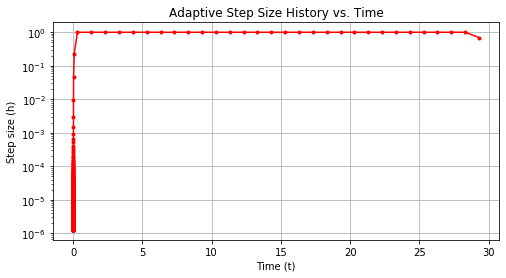

In [3]:

# I prompted Gemini 3.1 Pro to help me since I could not figure out how to do it
# I prompted prompt 1
def step_double_error(T_n, t_n, h, g_func, dg):
    # 1. Single full step of size h
    y_full, iters_full, success_full = damped_newton_raphson(T_n, t_n + h, h, g_func, dg)
    
    # 2. Two half-steps of size h/2
    y_half_1, iters_1, success_1 = damped_newton_raphson(T_n, t_n + h/2, h/2, g_func, dg)
    y_half, iters_2, success_2 = damped_newton_raphson(y_half_1, t_n + h, h/2, g_func, dg)
    
    # 3. Error estimate
    error = abs(y_half - y_full)
    total_iters = iters_full + iters_1 + iters_2
    all_success = success_full and success_1 and success_2
    
    return y_full, y_half, error, total_iters, all_success

# Adaptive Backward Euler
def backward_euler_adaptive(y0, t0, tf, h_init, tol, g_func, dg):
    t_values = [t0]
    y_values = [y0]
    h_values = []
    error_values = []
    
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'function_evals': 0
    }
    
    h = h_init
    t = t0
    y = y0
    safety = 0.9
    h_min = 1e-6
    h_max = 1.0
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t    
        
        y_full, y_half_2, error, iters, success = step_double_error(y, t, h, g_func, dg)
        stats['function_evals'] += iters
        
        # Adjust step size
        if error < 1e-14:
            h_new = min(2.0 * h, h_max)
            
        else:
            h_new = h * np.sqrt(tol / error)
            h_new = max(h_min, min(h_max, safety * h_new))
            h_new = max(0.2 * h, min(5.0 * h, h_new)) # Limit drastic changes
            
        # Accept or reject the step
        if error <= tol:
            t += h
            y = y_half_2
            t_values.append(t)
            y_values.append(y)
            h_values.append(h)
            error_values.append(error)
            stats['accepted_steps'] += 1
            h = h_new
            
        else:
            stats['rejected_steps'] += 1
            h = h_new
            
    return np.array(t_values), np.array(y_values), np.array(h_values), np.array(error_values), stats

# Execute the solver to fulfill the "Visualization of how h adapts" rubric requirement
tol_target = 1e-4
h0_adapt = 0.1
t_adapt, y_adapt, h_hist, err_hist, stats = backward_euler_adaptive(
    T0, t0, tf, h0_adapt, tol_target, g_func, dg
)

# Plotting Step Size Adaptation
plt.figure(figsize=(8, 4))
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.xlabel('Time (t)')
plt.ylabel('Step size (h)')
plt.title('Adaptive Step Size History vs. Time')
plt.grid(True)
plt.show()

The graph demonstrates a visualization of how the step size adapts to the solution throughout time.

Performance Comparison:
Method               Total Steps     Func Evals (NR Iters)    
------------------------------------------------------------
Fixed (h=0.01)       3000            3000                     
Adaptive (tol=1e-4)  1605            4836                     


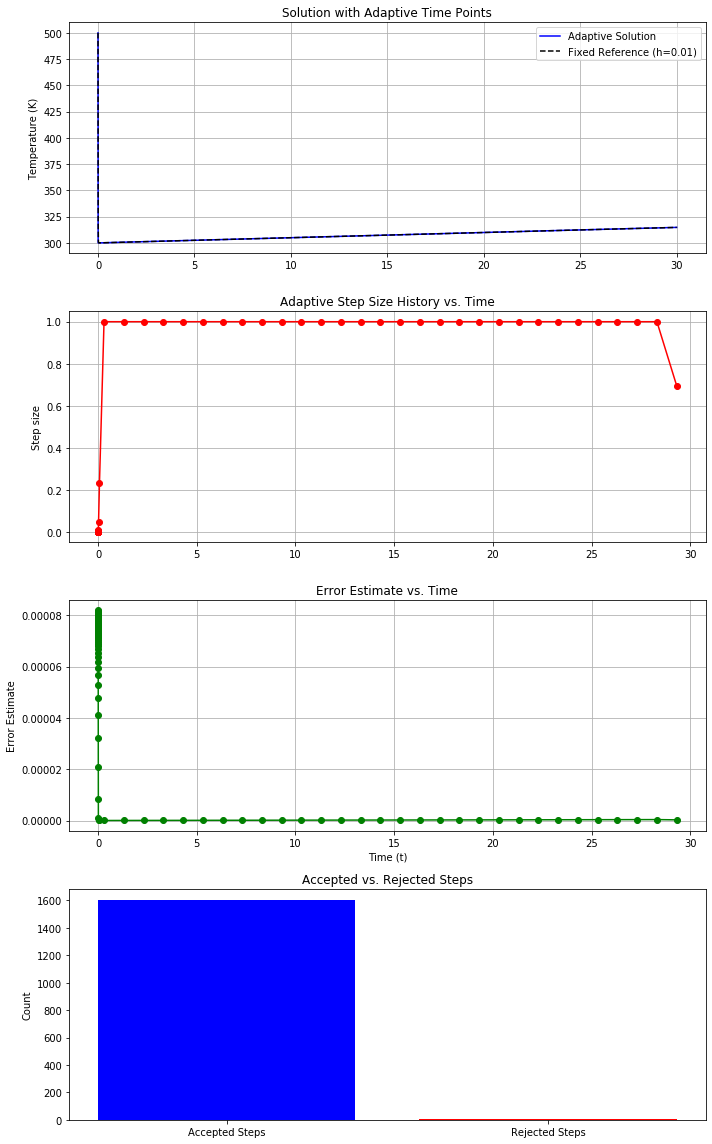

In [4]:
# Section 4:

# Backward Euler method
def backward_euler_newton(f, T0, t0, tf, h):
    
    t_values = np.arange(t0, tf + h, h)
    T_values = np.zeros_like(t_values)
    T_values[0] = T0    
    iteration_counts = []
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        T_prev = T_values[i - 1]     
        
        # Call the damped Newton-Raphson solver using the standardized g_func and dg
        T_next, count, success = damped_newton_raphson(T_prev, t_next, h, g_func, dg)
        
        # Use previous value as initial guess
        T_values[i] = T_next  
        iteration_counts.append(count)
        
    return t_values, T_values, iteration_counts
    
# Execution for Section 4 Comparison using your function
h_fixed = 0.01
t_fixed, y_fixed, iteration_counts = backward_euler_newton(f, T0, t0, tf, h_fixed)

# Calculate total evaluations for the comparison table
fixed_evals = sum(iteration_counts)

# 2. Adaptive Step Size Execution [cite: 994-997]
tol_target = 1e-4
h0_adapt = 0.1
t_adapt, y_adapt, h_hist, err_hist, stats = backward_euler_adaptive(
    T0, t0, tf, h0_adapt, tol_target, g_func, dg)

# I asked Gemini 3.1 Pro to generate table based on data
# 3. Text Output / Comparison Table
print("Performance Comparison:")
print(f"{'Method': <20} {'Total Steps': <15} {'Func Evals (NR Iters)': <25}")
print("-" * 60)
print(f"{'Fixed (h=0.01)': <20} {len(t_fixed)-1: <15} {fixed_evals: <25}")
print(f"{'Adaptive (tol=1e-4)': <20} {stats['accepted_steps']: <15} {stats['function_evals']: <25}")

# 4. Generating Required Plots
plt.figure(figsize=(10, 16))

# Plot A: Solution with adaptive time points
plt.subplot(4, 1, 1)
plt.plot(t_adapt, y_adapt, 'b', label='Adaptive Solution')
plt.plot(t_fixed, y_fixed, 'k--', label='Fixed Reference (h=0.01)')
plt.ylabel('Temperature (K)')
plt.title('Solution with Adaptive Time Points')
plt.legend()
plt.grid(True)

# Plot B: Step size h(t) vs. time
plt.subplot(4, 1, 2)
plt.plot(t_adapt[:-1], h_hist, 'r-o')
plt.ylabel('Step size')
plt.title('Adaptive Step Size History vs. Time')
plt.grid(True)

# Plot C: Error estimate vs. time
plt.subplot(4, 1, 3)
plt.plot(t_adapt[:-1], err_hist, 'g-o')
plt.ylabel('Error Estimate')
plt.xlabel('Time (t)')
plt.title('Error Estimate vs. Time')
plt.grid(True)

# Plot D: Accepted vs. Rejected steps
plt.subplot(4, 1, 4)
labels = ['Accepted Steps', 'Rejected Steps']
counts = [stats['accepted_steps'], stats['rejected_steps']]
plt.bar(labels, counts, color=['blue', 'red'])
plt.ylabel('Count')
plt.title('Accepted vs. Rejected Steps')


plt.tight_layout()
plt.show()


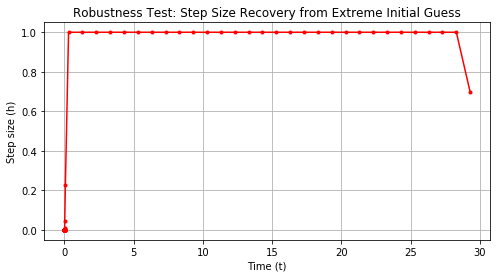

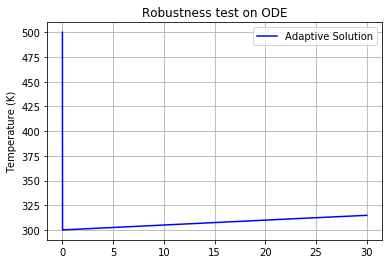

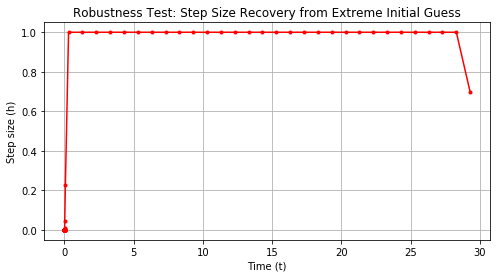

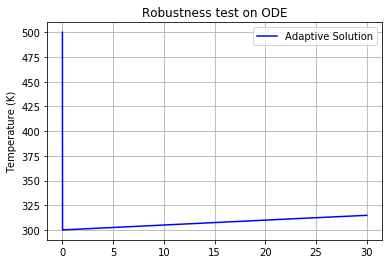

In [5]:
# Section 5:

# Robustness for high h0 value
tol_target = 1e-4
h0 = 5
t_adapt, y_adapt, h_hist, err_hist, stats = backward_euler_adaptive(
    T0, t0, tf, h0, tol_target, g_func, dg)

# Generate Robustness Plot
plt.figure(figsize=(8, 4))
plt.plot(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.xlabel('Time (t)')
plt.ylabel('Step size (h)')
plt.title('Robustness Test: Step Size Recovery from Extreme Initial Guess')
plt.grid(True)
plt.show()

plt.plot(t_adapt, y_adapt, 'b', label='Adaptive Solution')
plt.ylabel('Temperature (K)')
plt.title('Robustness test on ODE')
plt.legend()
plt.grid(True)
plt.show()


# Robustness for high tolerance
tol_target = 1e-4
h0 = 1
t_adapt, y_adapt, h_hist, err_hist, stats = backward_euler_adaptive(
    T0, t0, tf, h0, tol_target, g_func, dg)

# Generate Robustness Plot
plt.figure(figsize=(8, 4))
plt.plot(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.xlabel('Time (t)')
plt.ylabel('Step size (h)')
plt.title('Robustness Test: Step Size Recovery from Extreme Initial Guess')
plt.grid(True)
plt.show()

plt.plot(t_adapt, y_adapt, 'b', label='Adaptive Solution')
plt.ylabel('Temperature (K)')
plt.title('Robustness test on ODE')
plt.legend()
plt.grid(True)
plt.show()


Due to runtime, I will only do a tight tolerance of 1e-5, but the adaptive solver can still solve it. The only thing it requires, however, would be more time since the h step gets significantly smaller and the first phase of the ODE that causes the stiff exorberates it more. 

### Conlusion:
    Damping is necessary for allowing researchers to solve non-linear ODEs. Furthermore, damping allows researchers to have tighter tolerances and smaller step sizes so that they can have more accurate results while also not having to spend too much computational resources. Adaptive sizes are worth the complexity when the ODE has different phases between non-linearity and linearity. There could be sections where large steps are plausible, and others where small steps are necessary. Overall, I have learned to observe how dampening can affect complicated ODEs and when to use them. This will be useful since I am going to be in the aerospace industry, which requires tight tolerances.
    
    One note to say, the Damped NR cannot converge when the basic NR fails in this specific ODE due to the dg being constant and always converging to two. 

Appendix A
Prompt 1 w/context of previous code and goals of finding double step error
"def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):

y_next = y # Initial guess

for _ in range(max_iter):

g_val = y_next - y - h * f(t + h, y_next)

g_prime_val = 1 - h * fprime(y_next)

if abs(g_prime_val) < tol: # Avoid division by zero

break

y_new = y_next - g_val / g_prime_val

if abs(y_new - y_next) < tol:

return y_new # Converged

y_next = y_new

return y_next



does this work?"